**Imports for building**

---



In [ ]:
from ase import Atoms
from ase.build import make_supercell
from ase.data.pubchem import pubchem_atoms_search
from ase.io import read, write
from ase.visualize import view
from skopt import gp_minimize
from skopt.plots import plot_convergence, plot_gaussian_process
from skopt.space import Real
from skopt.utils import use_named_args
from operator import itemgetter
from tblite.ase import TBLite
import numpy as np
import os

**Build initial catalyst structure**

In [ ]:
# 1) Load template structure
PtC3N4 = pubchem_atoms_search(smiles="C1(=NC2=NC(=N)N=C3N2C(=NC(=N3)N)N1)N")

# 2) Rotate so the 7th and 8th atoms' vector lies along +x (rotate about atom 8 to avoid drift)
v = PtC3N4[7].position[:2] - PtC3N4[8].position[:2]
angle_deg = np.degrees(np.arctan2(v[1], v[0]))
PtC3N4.rotate(-angle_deg, 'z', center=PtC3N4[8].position)

# 3) Translate so the 8th atom is at the origin
PtC3N4.translate(-PtC3N4[8].position)

# 4) Set the unit cell
a_PtC3N4 = PtC3N4.get_distance(7, 8)
PtC3N4.set_cell([[a_PtC3N4, 0, 0], [a_PtC3N4/2, a_PtC3N4*(3**0.5)/2, 0], [0, 0, 15]], scale_atoms=False)
PtC3N4.set_pbc([True, True, False])

# 4) Delete atoms
del PtC3N4[9]
del PtC3N4[7]
del PtC3N4[[atom.index for atom in PtC3N4 if atom.symbol == 'H']]

# 5) Center at Pt
PtC3N4 += Atoms('Pt', positions=[[a_PtC3N4, a_PtC3N4*(3**0.5)/3, 0]])

## Move the molecule so that Pt is at [a_PtC3N4/2,(a_PtC3N4/2+a_PtC3N4*(3**0.5)/2)/2,4]
shift = PtC3N4.cell[:2,:2].sum(axis=0) / 2 - PtC3N4[-1].position[:2]
PtC3N4.translate([shift[0], shift[1], 4])

write('PtC3N4.xyz',PtC3N4)

view(PtC3N4, viewer='x3d')

**Add an adsorbate to the catalyst**

In [ ]:
# add adsorbate
PtC3N4_OH = PtC3N4 + Atoms('O', positions=[PtC3N4[-1].position + np.array([0,0,2.2])])
PtC3N4_OH += Atoms('H', positions=[PtC3N4_OH[-1].position + np.array([0,0.7,0.7])])

view(PtC3N4_OH, viewer='x3d')

**Imports for calculation**

In [ ]:
# imports for calculation
from ase.constraints import FixAtoms
from ase.optimize import GPMin
from tblite.ase import TBLite

**Downloads a nearly relaxed structure for example**

In [ ]:
%%capture
# first step for setting the calculation is cheating and getting a structure that is nearly relaxed since running it from the start is going to take to long for the examples.
!wget https://raw.githubusercontent.com/doublelayer/test_models/refs/heads/main/PtC3N4/PtC3N4_OH_lat7_near_relaxed.xyz

In [ ]:
#PtC3N4_OH = read('PtC3N4_OH_lat7_near_relaxed.xyz')
view(PtC3N4_OH, viewer='x3d')

**Set up calculation**

In [ ]:
# set calculator
PtC3N4_OH.set_constraint(FixAtoms(indices=[at.index for at in PtC3N4_OH if at.symbol not in ['O', 'H']]))
calculator = TBLite(method="GFN1-xTB")
PtC3N4_OH.calc = calculator

# run uptimization
dyn = GPMin(PtC3N4_OH, trajectory='PtC3N4_OH_relaxed.traj')
dyn.run(fmax=0.03)

# result
view(PtC3N4_OH, start_rotation=False)


Streaming output truncated to the last 5000 lines.
         2.90648079e-03,  5.63935853e-04,  4.85274717e-01,
         0.00000000e+00,  9.55208503e-01],
       [-1.09490300e-04,  5.31359576e-04, -3.98898986e-05,
        -1.66156763e-04, -1.50570422e-05, -2.37096494e-04,
        -2.12383646e-04,  1.02433493e-04,  1.14425622e-03,
         5.17518674e-05,  6.46604394e-05,  5.71490365e-05,
         6.05456392e-05,  1.18017831e-04, -3.21353447e-03,
         9.55208503e-01,  0.00000000e+00]]), 'molecular-dipole': array([ -2.32966379,  -0.62272204, -10.20973473])}
{'bond-orders': array([[ 0.00000000e+00,  3.18509230e-02,  2.52007211e-02,
         4.14957587e-02,  2.40463796e-02,  3.60936655e-02,
         4.39104782e-02,  4.20695784e-02,  1.05538904e+00,
         1.03382798e+00,  1.06260436e+00,  1.20777035e-02,
         1.72746780e-02,  9.72358051e-03,  2.29677930e-02,
         4.11132250e-04, -1.09490300e-04],
       [ 3.18509230e-02,  0.00000000e+00,  8.39234049e-02,
         3.96057034e-02

<Popen: returncode: None args: ['/usr/bin/python3', '-m', 'ase', 'gui', '-']>

In [ ]:
view(PtC3N4_OH*(3,3,1))
write('example_2_gp_min_final.xyz',PtC3N4_OH)

**Lattice optimisation** \
Here is a simple lattice calculator written with the GP method from scikit learn which can be adapted towards any problem.

it works by defyning a function which will create a structure with a given lattice parameter, then calculate the energi and returning it. We have the entire calculation within one function from structure create to returning only the energy, since scikit learn works with pure functions, meaning the varied arguments and return values must be a value.

We use a lambda decorator of the our step function when setting up the GP min object on line 62 to unpacked the argument vector of the varied arguments while keeping the calculator object the same.

Iteration No: 1 started. Evaluating function at random point.
------------------------------------------------------------
  cycle        total energy    energy error   density error
------------------------------------------------------------
      1     -41.07950284963  -4.1396306E+01   1.0235113E+00
      2     -39.53157109042   1.5479318E+00   9.0338702E-01
      3     -41.64059430376  -2.1090232E+00   5.0809700E-01
      4     -41.77806849101  -1.3747419E-01   3.6071378E-01
      5     -41.96851279848  -1.9044431E-01   2.7446887E-01
      6     -42.21183796659  -2.4332517E-01   2.5164960E-01
      7     -42.41688885645  -2.0505089E-01   1.4890565E-01
      8     -42.44661140412  -2.9722548E-02   1.0902926E-01
      9     -42.43177647925   1.4834925E-02   1.5121912E-01
     10     -42.52117931596  -8.9402837E-02   5.2246063E-02
     11     -42.52225478520  -1.0754692E-03   5.5223309E-02
     12     -42.45961258478   6.2642200E-02   1.2710483E-01
     13     -42.52364846192  -6.4035

<Axes: title={'center': 'x* = 7.7933, f(x*) = -1160.7695'}, xlabel='x', ylabel='f(x)'>

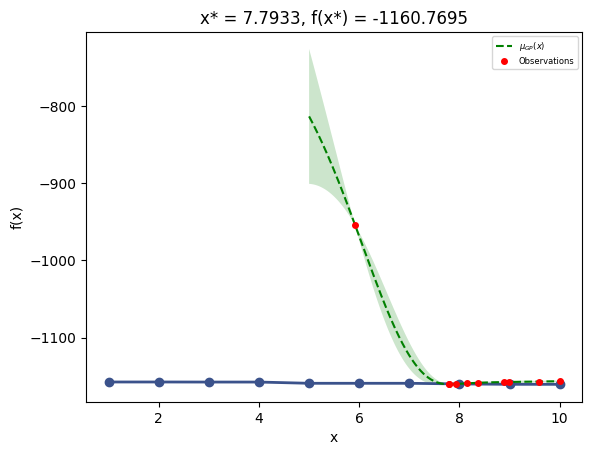

In [ ]:
# how to use GP_min from scikit to optimise any problem or parameter
# first example will be a simple problem of lattice parameter optimisation, often this can be done via Stress tensor implemented in gpaw, but for calculation methods where this is not implemented gp_min and other optimisations algorithm gives an alternative.
# for simplecity we will not be converging the structure at every step.

# first we start bt defining the function that will be called at every optimisation step.
# note for later this is more like the metal well being scaled but that ccan be fixed later
def lattice_calc(a: float, calculator) -> float:
    # as before we use the same the same steps for building the model, such that each opt step start with a fresh model.
    # 1) Load the template structure.
    PtC3N4 = pubchem_atoms_search(smiles="C1(=NC2=NC(=N)N=C3N2C(=NC(=N3)N)N1)N")

    # 2) Rotate so the 7–8 vector lies along +x (rotate about atom 8 to avoid drift)
    v = PtC3N4[7].position[:2] - PtC3N4[8].position[:2]
    angle_deg = np.degrees(np.arctan2(v[1], v[0]))
    PtC3N4.rotate(-angle_deg, 'z', center=PtC3N4[8].position)

    # 3) Translate so atom 8 is at the origin
    PtC3N4.translate(-PtC3N4[8].position)

    # 4) Set the unit cell
    a_PtC3N4 = a #PtC3N4.get_distance(7, 8)
    PtC3N4.set_cell([[a_PtC3N4, 0, 0], [a_PtC3N4/2, a_PtC3N4*(3**0.5)/2, 0], [0, 0, 15]], scale_atoms=False)
    PtC3N4.set_pbc([True, True, False])

    # 4) Delete atoms
    del PtC3N4[9]
    del PtC3N4[7]
    del PtC3N4[[atom.index for atom in PtC3N4 if atom.symbol == 'H']]

    # 5) Center at Pt
    PtC3N4 += Atoms('Pt', positions=[[a_PtC3N4, a_PtC3N4*(3**0.5)/3, 0]])
    shift = PtC3N4.cell[:2,:2].sum(axis=0) / 2 - PtC3N4[-1].position[:2]
    PtC3N4.translate([shift[0], shift[1], 4])

    # setting the calculation, and changing the txt to not overwrite in the file system
    PtC3N4.calc = calculator
    PtC3N4.calc.txt = f'PtC3N4_OH_a{a}.txt'

    # calculating the potential energy.
    # the step function needs to return a single value  to serve as objective value for the optimiser.
    return PtC3N4.get_potential_energy()

calculator = TBLite(method="GFN1-xTB")

# next the gp_min object
gp_min_obj = gp_minimize(
    # we here decorate the function with a lambda function, thereby setting the static arguments that does not change during the run. GP_min will give the set of paramenters as a list which needs to be unpackaged.
    # *par_list means the gp_minimize is able to optimize more than one variable at the same time, but in this case 1, the number of prameters is equal to the legnth of the dimensions
    func= lambda par_list: lattice_calc(*par_list, calculator=calculator),
    # each parameter to optimise have to be defined as a dimensions with an upper and lower bound
    dimensions= [Real(5, 10)], # guessing the energy minima is between 5 and 10 Å
    n_calls = 10, # the number of iterations to run, this gp_min does not appear to have convergen criteria...
    n_initial_points = 3, #  do 3 calculations at random points before beginning to estimate the space
    random_state = 42, # sets the random state for reproduction
    verbose= True, # for testing
)

print(f'minimum was found to be at {gp_min_obj.x} Å with and energy of {gp_min_obj.fun} eV')
plot_convergence(gp_min_obj)
plot_gaussian_process(gp_min_obj)

**Render the final structure**

In [ ]:
!wget https://raw.githubusercontent.com/doublelayer/test_models/refs/heads/main/PtC3N4/PtC3N4_OH_lat7_near_relaxed.xyz

FIXED_ROTATION = '45x, -35.264y, 210z'
prefix = 'PtC3N4_OH_lat7_near_relaxed'

atoms = read('PtC3N4_OH_lat7_near_relaxed.xyz')
from numpy import diag
atoms = make_supercell(atoms, diag([3, 2, 1]))

version_8_settings = {
    'generic_projection_settings': {
        'rotation': FIXED_ROTATION,
        'radii': 1.1,
        'colors': None,
        'show_unit_cell': 2,
    },
    'povray_settings': {
        'display': False,
        'transparent': True,
        'camera_type': 'orthographic',
        'camera_dist': 20,
        'canvas_width': 4096,
        'canvas_height': None,
        'depth_cueing': False,
        'point_lights': [
            [(30, 30, 50), 'White'],
            [(-30, -30, -50), 'Gray']
        ],
        'area_light': None,
    }
}

all_versions_map = {'v8': version_8_settings}
version_name = 'v8'
settings = all_versions_map[version_name]
gen_settings = settings['generic_projection_settings'].copy()
pov_settings = settings['povray_settings'].copy()

print(f"--- Rendering {version_name} ---")

pov_settings['textures'] = ['intermediate' for atom in atoms]
show_unit_cell_value = gen_settings.get('show_unit_cell', True)
gen_settings.pop('show_unit_cell', None)

output_file = f'{prefix}_{version_name}.pov'
write(
    output_file,
    atoms,
    show_unit_cell=show_unit_cell_value,
    **gen_settings,
    povray_settings=pov_settings
)

os.system(f'povray +I{output_file} +O{output_file.replace(".pov", ".png")} +A +AM2 +UA +Q9 +H1024')

--2026-03-08 22:30:43--  https://raw.githubusercontent.com/doublelayer/test_models/refs/heads/main/PtC3N4/PtC3N4_OH_lat7_near_relaxed.xyz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2256 (2.2K) [text/plain]
Saving to: ‘PtC3N4_OH_lat7_near_relaxed.xyz.1’

PtC3N4_OH_lat7_near 100%[===================>]   2.20K  --.-KB/s    in 0s      

2026-03-08 22:30:43 (37.0 MB/s) - ‘PtC3N4_OH_lat7_near_relaxed.xyz.1’ saved [2256/2256]

--- Rendering v8 ---


0